In [28]:
import numpy as np
def process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps,resampling_factor=1):
    ref_samples = np.fromfile(fileName_ref, np.complex64)
    rx_samples = np.fromfile(fileName_rx, np.complex64) 
    print("ref_samples size: ", ref_samples.size)
    print("rx_samples size: ", rx_samples.size)

    #normalise samples
    # ref_samples = low_pass_filter(500e3,5e6,4,ref_samples)
    # rx_samples = low_pass_filter(500e3,5e6,4,rx_samples)
    # ref_samples = normaliseSignals(ref_samples,burst_len,num_steps)
    # rx_samples = normaliseSignals(rx_samples,burst_len,num_steps)

    #reshape samples into busrt
    rx_samples_reshaped = rx_samples.reshape([num_steps,-1])
    #rx_samples_reshaped = signal.resample(rx_samples_reshaped,int(burst_len*resampling_factor),axis=1)
    #rx_samples_reshaped = signal.resample_poly(rx_samples_reshaped,resampling_factor,1,axis=1)
    ref_samples_reshaped = ref_samples.reshape([num_steps,-1])
    #ref_samples_reshaped = signal.resample(ref_samples_reshaped,int(burst_len*resampling_factor),axis=1)
    #ref_samples_reshaped = signal.resample_poly(ref_samples_reshaped,resampling_factor,1,axis=1)

    #drop noisy samples
    # rx_samples_reshaped = rx_samples_reshaped[:,100:100+int(burst_len/2)]
    # ref_samples_reshaped = ref_samples_reshaped[:,100:100+int(burst_len/2)]

    return rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples

In [29]:


def generate_ascan_from_cw(
    echo_signals: np.ndarray,
    reference_signals: np.ndarray,
    num_steps: int,
    step_length: int,
    baseband_freq_hz: float,
    sampling_rate_hz: float
) -> np.ndarray:
    """
    Generates an A-scan range profile for a single-tone CW SFCW radar.

    This function performs phase coherence compensation by dividing the echo
    signal by a reference signal in the frequency domain and then applies an
    IFFT to synthesize the time-domain range profile.

    Args:
        echo_signals: A 1D numpy array containing the concatenated raw IQ
                      samples from the target echo channel.
        reference_signals: A 1D numpy array containing the concatenated raw IQ
                           samples from the reference (loopback) channel.
        num_steps: The total number of frequency steps in the sweep.
        step_length: The number of IQ samples recorded for each frequency step.
        baseband_freq_hz: The known frequency of the CW tone at baseband (in Hz).
        sampling_rate_hz: The sampling rate of the SDR's ADC (in Hz).

    Returns:
        A 1D numpy array representing the complex A-scan (range profile).
    """
    # Reshape the 1D arrays into 2D arrays of (num_steps, step_length)
    echo_matrix = echo_signals.reshape(num_steps, step_length)
    ref_matrix = reference_signals.reshape(num_steps, step_length)

    # Calculate the index of the FFT bin corresponding to the baseband frequency
    baseband_bin = int(baseband_freq_hz / sampling_rate_hz * step_length)

    # --- Step 1: Extract Complex Channel Response for Each Frequency Step ---
    # Perform FFT on each step's data (row-wise)
    echo_fft = np.fft.fft(echo_matrix, axis=1)
    ref_fft = np.fft.fft(ref_matrix, axis=1)

    # Extract the complex amplitude at the baseband frequency bin for all steps
    echo_response = echo_fft[:, baseband_bin]
    ref_response = ref_fft[:, baseband_bin]

    # --- Step 2: Perform Phase Coherence Compensation ---
    # Divide the echo response by the reference response to cancel phase error
    # Add a small epsilon to the denominator to avoid division by zero
    epsilon = 1e-12
    calibrated_frequency_response = echo_response / (ref_response + epsilon)

    # --- Step 3: Synthesize the A-scan (Range Profile) ---
    # Apply an IFFT to the coherent frequency response vector
    # np.fft.ifftshift is used to center the main peak in the resulting profile
    #a_scan = np.fft.ifftshift(np.fft.ifft(calibrated_frequency_response))
    a_scan = np.fft.ifft(calibrated_frequency_response)

    return a_scan

# if __name__ == '__main__':
#     # --- Example Usage ---
#     # Define radar parameters for a simulation
#     NUM_STEPS = 256        # Number of frequency steps
#     STEP_LENGTH = 1024     # Samples per step
#     SAMPLING_RATE = 1e6    # 1 MHz
#     BASEBAND_FREQ = 10e3   # 10 kHz

#     # --- Simulate a target ---
#     # This simulates a target at a specific time delay
#     target_delay_samples = 50
#     target_phase_shift = np.exp(-1j * 2 * np.pi * np.arange(NUM_STEPS) * target_delay_samples / NUM_STEPS)
#     target_amplitude = 0.5

#     # Simulate a random phase error for each step (the problem we need to solve)
#     random_phase_error = np.exp(1j * np.random.uniform(0, 2 * np.pi, NUM_STEPS))

#     # Create the ideal calibrated frequency response of the target
#     H_target = target_amplitude * target_phase_shift

#     # --- Simulate the received signals ---
#     # The 'received' frequency response is corrupted by the random phase error
#     echo_response_corrupted = H_target * random_phase_error
#     # The reference channel captures the same random phase error
#     ref_response_corrupted = 1.0 * random_phase_error # Assuming ref path has amplitude 1

#     # To simulate the time-domain signals, we modulate a sine wave
#     # (This is a simplified simulation for demonstration purposes)
#     t = np.arange(STEP_LENGTH) / SAMPLING_RATE
#     baseband_wave = np.exp(1j * 2 * np.pi * BASEBAND_FREQ * t)

#     # Create the full time-domain signals by repeating the baseband wave
#     # and multiplying by the corrupted frequency response
#     sim_echo_signals = (echo_response_corrupted[:, np.newaxis] * baseband_wave).flatten()
#     sim_ref_signals = (ref_response_corrupted[:, np.newaxis] * baseband_wave).flatten()

#     # Add some noise to the simulated signals
#     noise_power = 0.01
#     sim_echo_signals += (np.random.randn(len(sim_echo_signals)) + 1j * np.random.randn(len(sim_echo_signals))) * np.sqrt(noise_power / 2)
#     sim_ref_signals += (np.random.randn(len(sim_ref_signals)) + 1j * np.random.randn(len(sim_ref_signals))) * np.sqrt(noise_power / 2)

#     # --- Generate the A-scan using the function ---
#     ascan_profile = generate_ascan_from_cw(
#         echo_signals=sim_echo_signals,
#         reference_signals=sim_ref_signals,
#         num_steps=NUM_STEPS,
#         step_length=STEP_LENGTH,
#         baseband_freq_hz=BASEBAND_FREQ,
#         sampling_rate_hz=SAMPLING_RATE
#     )

#     # --- Plot the result ---
#     try:
#         import matplotlib.pyplot as plt
#         plt.figure(figsize=(10, 6))
#         plt.plot(np.abs(ascan_profile))
#         plt.title("Generated A-Scan (Range Profile)")
#         plt.xlabel("Range Bin")
#         plt.ylabel("Magnitude")
#         plt.grid(True)
#         # The peak should be off-center due to the ifftshift and the simulated delay
#         peak_location = np.argmax(np.abs(ascan_profile))
#         plt.axvline(x=peak_location, color='r', linestyle='--', label=f'Target Peak at bin {peak_location}')
#         plt.legend()
#         print(f"Generated A-scan. Target peak found at range bin: {peak_location}")
#         plt.show()

#     except ImportError:
#         print("Matplotlib not found. Please install it to see the plot (`pip install matplotlib`).")
#         print(f"Generated A-scan. Target peak found at range bin: {np.argmax(np.abs(ascan_profile))}")

In [30]:
SAMPLING_RATE = 5e6    # 5 MHz
BASEBAND_FREQ = 100e3   # 100 kHz
burst_len = 1024+64
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/gui/'
prefix = 'loop_back_cw'
i=0
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps)

ref_samples size:  139264
rx_samples size:  139264


Generated A-scan. Target peak found at range bin: 4


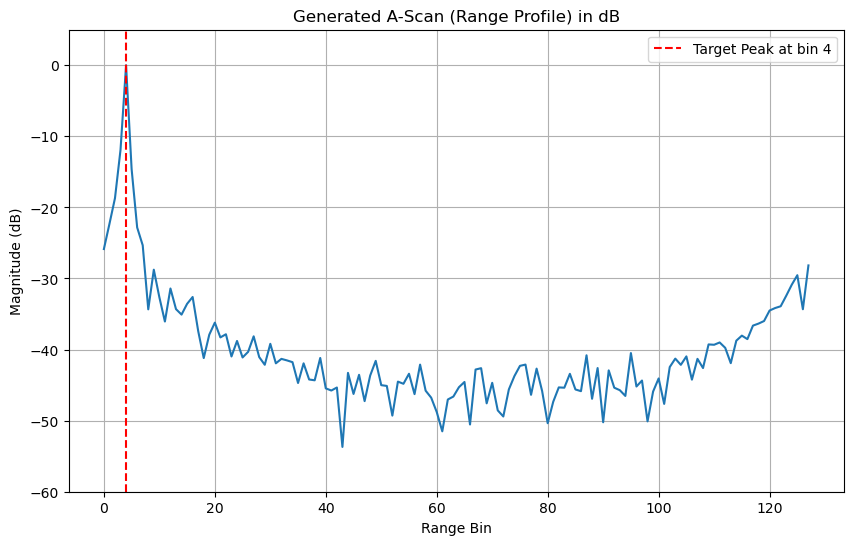

In [31]:
    # --- Generate the A-scan using the function ---
    ascan_profile = generate_ascan_from_cw(
        echo_signals=rx_samples,
        reference_signals=ref_samples,
        num_steps=num_steps,
        step_length=burst_len,
        baseband_freq_hz=BASEBAND_FREQ,
        sampling_rate_hz=SAMPLING_RATE
    )

    # --- Plot the result ---
    try:
        import matplotlib.pyplot as plt
        
        # --- MODIFICATION START ---
        
        # Calculate the magnitude of the A-scan
        magnitude = np.abs(ascan_profile)
        
        # Normalize the magnitude so the peak is at 1.0 (or 0 dB)
        normalized_magnitude = magnitude / np.max(magnitude)
        
        # Convert to decibels (dB). Add a small epsilon to avoid log10(0).
        ascan_db = 20 * np.log10(normalized_magnitude + 1e-9)
        
        plt.figure(figsize=(10, 6))
        plt.plot(ascan_db)
        plt.title("Generated A-Scan (Range Profile) in dB")
        plt.xlabel("Range Bin")
        plt.ylabel("Magnitude (dB)")
        plt.grid(True)
        plt.ylim(-60, 5) # Set a reasonable y-axis limit to see the noise floor
        
        peak_location = np.argmax(ascan_db)
        plt.axvline(x=peak_location, color='r', linestyle='--', label=f'Target Peak at bin {peak_location}')
        plt.legend()
        print(f"Generated A-scan. Target peak found at range bin: {peak_location}")
        
        # --- MODIFICATION END ---
        
        plt.show()

    except ImportError:
        print("Matplotlib not found. Please install it to see the plot (`pip install matplotlib`).")
        print(f"Generated A-scan. Target peak found at range bin: {np.argmax(np.abs(ascan_profile))}")

In [32]:
def calculate_snr(a_scan: np.ndarray, exclusion_width: int = 5) -> float:
    """
    Calculates the Signal-to-Noise Ratio (SNR) of a radar A-scan.

    The SNR is calculated as the ratio of the peak signal power to the
    average noise power in the profile.

    Args:
        a_scan: A 1D numpy array containing the complex or real A-scan data.
        exclusion_width: The number of samples around the peak to exclude
                         from the noise calculation. Must be an odd number.

    Returns:
        The calculated SNR in decibels (dB).
    """
    if exclusion_width % 2 == 0:
        raise ValueError("Exclusion width must be an odd number.")

    # --- 1. Calculate Magnitudes and Find Peak Signal Power ---
    # Use np.abs() to handle both real and complex inputs
    magnitudes = np.abs(a_scan)
    signal_peak_magnitude = np.max(magnitudes)
    signal_power = signal_peak_magnitude**2
    peak_index = np.argmax(magnitudes)

    # --- 2. Identify and Calculate Average Noise Power ---
    # Create a copy of the magnitudes to use for noise calculation
    noise_magnitudes = magnitudes.copy()
    
    # Define the exclusion zone around the peak
    half_width = exclusion_width // 2
    start_exclusion = max(0, peak_index - half_width)
    end_exclusion = min(len(a_scan), peak_index + half_width + 1)
    
    # Set the values in the exclusion zone to NaN (Not a Number)
    noise_magnitudes[start_exclusion:end_exclusion] = np.nan
    
    # Calculate the average noise power using nanmean, which ignores NaNs
    average_noise_power = np.nanmean(noise_magnitudes**2)
    
    # --- 3. Calculate SNR in dB ---
    # Add a small epsilon to avoid log10(0) if noise power is zero
    epsilon = 1e-12
    snr_ratio = signal_power / (average_noise_power + epsilon)
    snr_db = 10 * np.log10(snr_ratio)

    return snr_db

In [33]:
calculate_snr(ascan_profile)

np.float32(36.397327)